In [4]:
# ============================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "Default"
SAMPLE_SIZE = 6000

In [5]:
# ============================================================
# CELL 2: LOAD ORIGINAL DATASET
# ============================================================

# Load the complete training dataset.
# We deliberately start with all 121K records because this
# represents the original population available for modelling.

df = pd.read_csv("/content/dataset/Train_Dataset.csv", low_memory=False)

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

display(df.head())

Dataset Shape: (121856, 40)
Number of Rows: 121856
Number of Columns: 40


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655054,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631354537,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355638717,0.2021,674.0,1.0,0


In [6]:
# ============================================================
# CELL 3: ANALYZE TARGET VARIABLE / CLASS IMBALANCE
# ============================================================

target_counts = df[TARGET].value_counts()
target_percent = df[TARGET].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

display(target_summary)

print("\nClass imbalance ratio:")
print(
    f"Non-Default : Default = "
    f"{target_counts[0]} : {target_counts[1]}"
)

,Count,Percentage
Default,,
0,112011,91.92
1,9845,8.08



Class imbalance ratio:
Non-Default : Default = 112011 : 9845


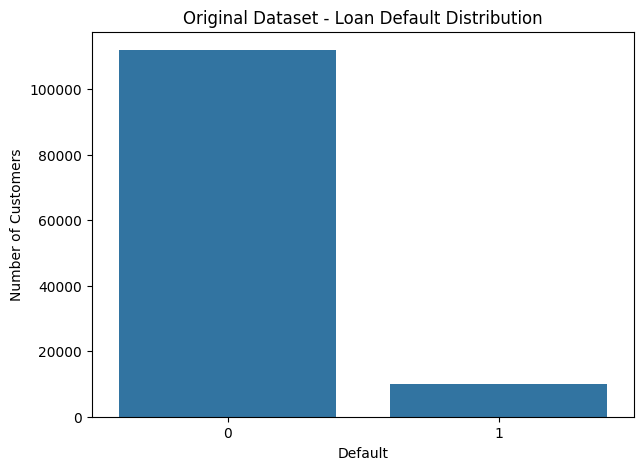

In [7]:
# ============================================================
# CELL 3B: VISUALIZE CLASS IMBALANCE
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=TARGET)

plt.title("Original Dataset - Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Customers")

plt.show()

In [8]:
# ============================================================
# CELL 4: CHECK DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:",
      round(duplicate_count / len(df) * 100, 2), "%")

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


In [9]:
# Check whether ID is unique
print("Unique IDs:", df["ID"].nunique())
print("Total records:", len(df))

if df["ID"].nunique() == len(df):
    print("Each record has a unique ID.")
else:
    print("Duplicate IDs exist.")

Unique IDs: 121856
Total records: 121856
Each record has a unique ID.


In [10]:
# ============================================================
# CELL 5: MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing_Percentage", ascending=False)
)

display(missing_summary.head(15))

,Missing_Count,Missing_Percentage
Own_House_Age,80095,65.73
Score_Source_1,68835,56.49
Social_Circle_Default,61928,50.82
Client_Occupation,41435,34.00
Score_Source_3,26921,22.09
Credit_Bureau,18540,15.21
ID_Days,5968,4.90
Score_Source_2,5686,4.67
Population_Region_Relative,4857,3.99
Loan_Annuity,4812,3.95


In [11]:
# ============================================================
# CELL 6: IDENTIFY NUMERIC VARIABLES STORED AS OBJECT
# ============================================================

object_columns = df.select_dtypes(include="object").columns.tolist()

print("Object columns:")
print(object_columns)

Object columns:
['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Accompany_Client', 'Client_Income_Type', 'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 'Client_Housing_Type', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 'Registration_Days', 'ID_Days', 'Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 'Type_Organization', 'Score_Source_3']


In [12]:
# ============================================================
# CELL 7: CREATE TEMPORARY VARIABLES FOR REPRESENTATIVE
# SAMPLING
# ============================================================

sampling_df = df.copy()

# ------------------------------------------------------------
# Convert important numeric-looking columns into numeric form.
# errors='coerce' converts invalid values to NaN rather than
# causing the notebook to fail.
# ------------------------------------------------------------

sampling_df["Income_Num"] = pd.to_numeric(
    sampling_df["Client_Income"],
    errors="coerce"
)

sampling_df["Credit_Amount_Num"] = pd.to_numeric(
    sampling_df["Credit_Amount"],
    errors="coerce"
)

sampling_df["Age_Days_Num"] = pd.to_numeric(
    sampling_df["Age_Days"],
    errors="coerce"
)

print("Temporary sampling variables created.")

Temporary sampling variables created.


In [13]:
# ============================================================
# CELL 8: CREATE QUANTILE-BASED GROUPS
# ============================================================

# Divide each numerical variable into 4 approximately equal
# population groups.
#
# This prevents the sampling process from being dominated by
# a few extreme numerical values.

sampling_df["Income_Group"] = pd.qcut(
    sampling_df["Income_Num"],
    q=4,
    labels=False,
    duplicates="drop"
)

sampling_df["Credit_Group"] = pd.qcut(
    sampling_df["Credit_Amount_Num"],
    q=4,
    labels=False,
    duplicates="drop"
)

sampling_df["Age_Group"] = pd.qcut(
    sampling_df["Age_Days_Num"],
    q=4,
    labels=False,
    duplicates="drop"
)

# Replace missing values with a separate category.
for col in ["Income_Group", "Credit_Group", "Age_Group"]:
    sampling_df[col] = (
        sampling_df[col]
        .astype("object")
        .where(
            sampling_df[col].notna(),
            "Missing"
        )
    )

print("Quantile groups created.")

Quantile groups created.


In [14]:
# ============================================================
# CELL 9: STANDARDIZE GENDER FOR SAMPLING
# ============================================================

# Keep the two major categories separately.
# Rare/unknown values are grouped together so that very small
# strata do not create unstable sampling groups.

sampling_df["Gender_Group"] = sampling_df["Client_Gender"].where(
    sampling_df["Client_Gender"].isin(["Male", "Female"]),
    "Other/Missing"
)

print(
    sampling_df["Gender_Group"]
    .value_counts(dropna=False)
)

Gender_Group
Male             78463
Female           40977
Other/Missing     2416
Name: count, dtype: int64


In [15]:
# ============================================================
# CELL 10: CREATE MULTI-DIMENSIONAL SAMPLING STRATA
# ============================================================

# Each stratum represents a combination of:
#
# 1. Default status
# 2. Income group
# 3. Credit amount group
# 4. Age group
# 5. Gender group
#
# Therefore, sampling will preserve not only the target
# distribution but also important characteristics of the
# customer population.

sampling_df["Sampling_Stratum"] = (
    sampling_df[
        [
            TARGET,
            "Income_Group",
            "Credit_Group",
            "Age_Group",
            "Gender_Group"
        ]
    ]
    .astype(str)
    .agg("_".join, axis=1)
)

print(
    "Number of initial strata:",
    sampling_df["Sampling_Stratum"].nunique()
)

Number of initial strata: 677


In [16]:
# ============================================================
# CELL 11: HANDLE VERY SMALL STRATA
# ============================================================

stratum_counts = sampling_df["Sampling_Stratum"].value_counts()

MIN_STRATUM_SIZE = 50

small_strata = stratum_counts[
    stratum_counts < MIN_STRATUM_SIZE
].index

sampling_df["Final_Stratum"] = sampling_df["Sampling_Stratum"]

# Combine very small strata while preserving Default status.
small_mask = sampling_df["Sampling_Stratum"].isin(small_strata)

sampling_df.loc[small_mask, "Final_Stratum"] = (
    sampling_df.loc[small_mask, TARGET].astype(str)
    + "_RARE"
)

print("Initial number of strata:", len(stratum_counts))
print("Final number of strata:",
      sampling_df["Final_Stratum"].nunique())

Initial number of strata: 677
Final number of strata: 302


In [17]:
# ============================================================
# CELL 12: PROPORTIONAL STRATIFIED SAMPLING
# ============================================================

# We want exactly 6,000 observations while maintaining the
# proportional representation of every final sampling stratum.

TARGET_SAMPLE_SIZE = 6000

stratum_counts = (
    sampling_df["Final_Stratum"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Step 1: Calculate the ideal number of observations that
# should come from each stratum.
# ------------------------------------------------------------

ideal_allocation = (
    stratum_counts / len(sampling_df)
) * TARGET_SAMPLE_SIZE

# Take the integer/floor part initially.
allocation = np.floor(ideal_allocation).astype(int)

# ------------------------------------------------------------
# Step 2: We may have a few remaining records because of
# rounding. Allocate those records to strata having the
# largest decimal remainders.
# ------------------------------------------------------------

remaining = TARGET_SAMPLE_SIZE - allocation.sum()

remainders = (
    ideal_allocation - allocation
).sort_values(ascending=False)

for stratum in remainders.index[:remaining]:
    allocation.loc[stratum] += 1

print("Requested sample size:", TARGET_SAMPLE_SIZE)
print("Allocated sample size:", allocation.sum())

# ------------------------------------------------------------
# Step 3: Randomly sample the allocated number of records
# from each stratum.
# ------------------------------------------------------------

sample_parts = []

for stratum, n_records in allocation.items():

    stratum_data = sampling_df[
        sampling_df["Final_Stratum"] == stratum
    ]

    sampled_part = stratum_data.sample(
        n=n_records,
        random_state=RANDOM_STATE
    )

    sample_parts.append(sampled_part)

# Combine all sampled strata
sample_6k = pd.concat(
    sample_parts,
    axis=0
)

# Shuffle the final dataset so that records are not grouped
# according to their sampling strata.
sample_6k = sample_6k.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("\nOriginal dataset size:", len(sampling_df))
print("Final sample size:", len(sample_6k))

Requested sample size: 6000
Allocated sample size: 6000

Original dataset size: 121856
Final sample size: 6000


In [18]:
# ============================================================
# CELL 13: CREATE FINAL 6K DATASET
# ============================================================

# Remove all temporary sampling variables.
# Retain only the original dataset columns.

original_columns = df.columns.tolist()

df_6000 = sample_6k[original_columns].copy()

print("Final dataset shape:", df_6000.shape)

display(df_6000.head())

Final dataset shape: (6000, 40)


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12159979,14400,0.0,0.0,0.0,0.0,0.0,18000,900,Alone,...,No,Yes,NaN,NaN,0.120221,0.443615308,NaN,222.0,0.0,0
1,12175950,18000,1.0,0.0,0.0,1.0,0.0,125865,5345.55,Alone,...,Yes,Yes,XNA,0.454094,0.651952,0.684827659,NaN,1390.0,7.0,0
2,12157529,11250,1.0,0.0,1.0,0.0,0.0,13500,675,Alone,...,Yes,No,Industry: type 3,NaN,0.542806,0.239226279,NaN,386.0,2.0,0
3,12155010,13500,NaN,1.0,1.0,1.0,0.0,49182.3,2179.35,Alone,...,Yes,Yes,XNA,NaN,0.239451,0.641368257,NaN,0.0,3.0,0
4,12121412,29250,0.0,0.0,1.0,1.0,5.0,NaN,3584.25,Alone,...,Yes,No,Industry: type 6,NaN,0.717942,0.549596502,0.067,1761.0,6.0,0


In [19]:
# ============================================================
# CELL 14: COMPARE TARGET DISTRIBUTION
# ============================================================

original_target_pct = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
)

sample_target_pct = (
    df_6000[TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
)

comparison_target = pd.DataFrame({
    "Original_121K_%": original_target_pct,
    "Sample_6K_%": sample_target_pct
})

comparison_target["Difference_%"] = (
    comparison_target["Sample_6K_%"]
    - comparison_target["Original_121K_%"]
)

display(comparison_target)

,Original_121K_%,Sample_6K_%,Difference_%
Default,,,
0,91.920792,91.966667,0.045875
1,8.079208,8.033333,-0.045875


In [20]:
# ============================================================
# CELL 14B: FINAL CLASS BALANCE VALIDATION
# ============================================================

original_counts = df[TARGET].value_counts().sort_index()
sample_counts = df_6000[TARGET].value_counts().sort_index()

class_comparison = pd.DataFrame({
    "Original_Count": original_counts,
    "Sample_Count": sample_counts,
    "Original_%": (
        original_counts / len(df) * 100
    ),
    "Sample_%": (
        sample_counts / len(df_6000) * 100
    )
})

class_comparison["Percentage_Difference"] = (
    class_comparison["Sample_%"]
    - class_comparison["Original_%"]
)

display(class_comparison.round(3))

,Original_Count,Sample_Count,Original_%,Sample_%,Percentage_Difference
Default,,,,,
0,112011,5518,91.921,91.967,0.046
1,9845,482,8.079,8.033,-0.046


In [21]:
# ============================================================
# CELL 15: NUMERICAL DISTRIBUTION COMPARISON
# ============================================================

numeric_sampling_columns = [
    "Income_Num",
    "Credit_Amount_Num",
    "Age_Days_Num"
]

distribution_results = []

for col in numeric_sampling_columns:

    # Original population
    original_values = sampling_df[col].dropna()

    # Sample
    sample_values = pd.to_numeric(
        df_6000[
            {
                "Income_Num": "Client_Income",
                "Credit_Amount_Num": "Credit_Amount",
                "Age_Days_Num": "Age_Days"
            }[col]
        ],
        errors="coerce"
    ).dropna()

    # Kolmogorov-Smirnov test compares the two distributions.
    ks_stat, p_value = ks_2samp(
        original_values,
        sample_values
    )

    distribution_results.append({
        "Variable": col,
        "Original_Mean": original_values.mean(),
        "Sample_Mean": sample_values.mean(),
        "Original_Median": original_values.median(),
        "Sample_Median": sample_values.median(),
        "KS_Statistic": ks_stat,
        "KS_p_value": p_value
    })

distribution_results = pd.DataFrame(distribution_results)

display(
    distribution_results.round(4)
)

,Variable,Original_Mean,Sample_Mean,Original_Median,Sample_Median,KS_Statistic,KS_p_value
0,Income_Num,16865.1917,16880.6587,14400.0,14400.0,0.0042,1.0000
1,Credit_Amount_Num,60046.4890,60077.2137,51750.0,51856.2,0.0046,0.9998
2,Age_Days_Num,16027.4229,16018.7767,15734.0,15741.0,0.0056,0.9943


In [22]:
# ============================================================
# CELL 16: CATEGORICAL DISTRIBUTION VALIDATION
# ============================================================

categorical_columns = [
    "Client_Gender",
    "Client_Education",
    "Client_Marital_Status",
    "Client_Housing_Type"
]

for col in categorical_columns:

    print("\n" + "=" * 70)
    print(f"VARIABLE: {col}")
    print("=" * 70)

    original_dist = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .rename("Original_%")
    )

    sample_dist = (
        df_6000[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .rename("Sample_%")
    )

    comparison = pd.concat(
        [original_dist, sample_dist],
        axis=1
    ).fillna(0)

    comparison["Difference_%"] = (
        comparison["Sample_%"]
        - comparison["Original_%"]
    )

    display(comparison.round(2))


VARIABLE: Client_Gender


,Original_%,Sample_%,Difference_%
Client_Gender,,,
Male,64.39,64.38,-0.01
Female,33.63,33.55,-0.08
NaN,1.98,2.07,0.09
XNA,0.00,0.00,-0.00



VARIABLE: Client_Education


,Original_%,Sample_%,Difference_%
Client_Education,,,
Secondary,68.86,68.97,0.11
Graduation,23.65,23.83,0.18
Graduation dropout,3.25,3.02,-0.23
NaN,2.99,2.85,-0.14
Junior secondary,1.19,1.33,0.14
Post Grad,0.05,0.00,-0.05



VARIABLE: Client_Marital_Status


,Original_%,Sample_%,Difference_%
Client_Marital_Status,,,
M,71.68,71.15,-0.53
S,14.28,14.87,0.58
D,6.20,6.43,0.23
W,4.98,4.88,-0.10
NaN,2.85,2.67,-0.18



VARIABLE: Client_Housing_Type


,Original_%,Sample_%,Difference_%
Client_Housing_Type,,,
Home,86.06,85.33,-0.73
Family,4.75,5.03,0.29
Municipal,3.49,3.38,-0.10
NaN,3.03,3.22,0.19
Rental,1.49,1.70,0.21
Office,0.82,0.82,-0.01
Shared,0.37,0.52,0.15


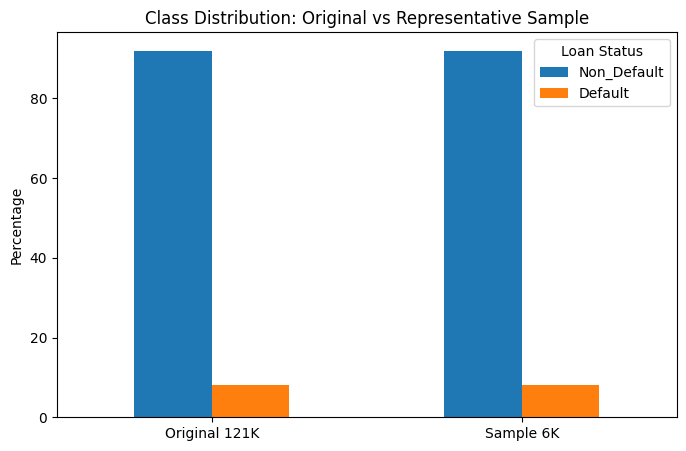

In [23]:
# ============================================================
# CELL 17: VISUAL COMPARISON OF TARGET DISTRIBUTION
# ============================================================

comparison_plot = pd.DataFrame({
    "Dataset": [
        "Original 121K",
        "Sample 6K"
    ],
    "Non_Default": [
        (df[TARGET] == 0).mean() * 100,
        (df_6000[TARGET] == 0).mean() * 100
    ],
    "Default": [
        (df[TARGET] == 1).mean() * 100,
        (df_6000[TARGET] == 1).mean() * 100
    ]
})

comparison_plot.set_index("Dataset").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Distribution: Original vs Representative Sample")
plt.ylabel("Percentage")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

plt.show()

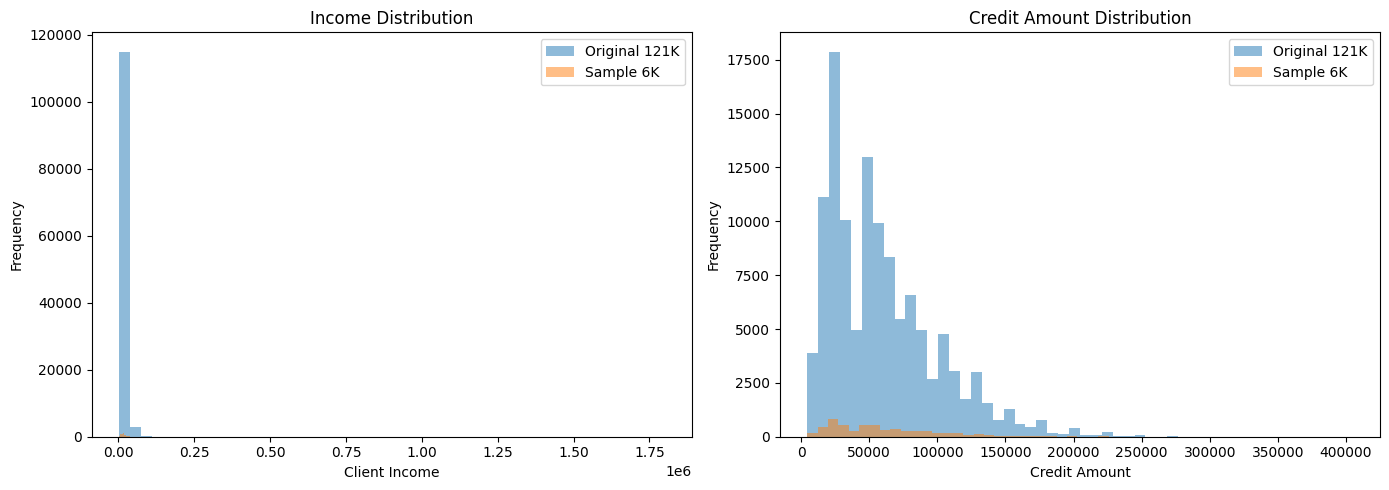

In [24]:
# ============================================================
# CELL 18: DISTRIBUTION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income
axes[0].hist(
    sampling_df["Income_Num"].dropna(),
    bins=50,
    alpha=0.5,
    label="Original 121K"
)

axes[0].hist(
    pd.to_numeric(
        df_6000["Client_Income"],
        errors="coerce"
    ).dropna(),
    bins=50,
    alpha=0.5,
    label="Sample 6K"
)

axes[0].set_title("Income Distribution")
axes[0].set_xlabel("Client Income")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Credit Amount
axes[1].hist(
    sampling_df["Credit_Amount_Num"].dropna(),
    bins=50,
    alpha=0.5,
    label="Original 121K"
)

axes[1].hist(
    pd.to_numeric(
        df_6000["Credit_Amount"],
        errors="coerce"
    ).dropna(),
    bins=50,
    alpha=0.5,
    label="Sample 6K"
)

axes[1].set_title("Credit Amount Distribution")
axes[1].set_xlabel("Credit Amount")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 19: FINAL REPRESENTATIVENESS REPORT
# ============================================================

print("=" * 70)
print("REPRESENTATIVE SAMPLING VALIDATION REPORT")
print("=" * 70)

print(f"\nOriginal dataset size : {len(df):,}")
print(f"Sample dataset size   : {len(df_6000):,}")

print(
    f"\nOriginal default rate : "
    f"{df[TARGET].mean() * 100:.2f}%"
)

print(
    f"Sample default rate   : "
    f"{df_6000[TARGET].mean() * 100:.2f}%"
)

print(
    f"\nOriginal non-defaults : "
    f"{(df[TARGET] == 0).sum():,}"
)

print(
    f"Original defaults     : "
    f"{(df[TARGET] == 1).sum():,}"
)

print(
    f"\nSample non-defaults   : "
    f"{(df_6000[TARGET] == 0).sum():,}"
)

print(
    f"Sample defaults       : "
    f"{(df_6000[TARGET] == 1).sum():,}"
)

print("\nSampling methodology:")
print("✓ Target class distribution preserved")
print("✓ Income distribution considered")
print("✓ Credit amount distribution considered")
print("✓ Age distribution considered")
print("✓ Gender distribution considered")
print("✓ Random seed fixed for reproducibility")
print("✓ Statistical validation performed")

REPRESENTATIVE SAMPLING VALIDATION REPORT

Original dataset size : 121,856
Sample dataset size   : 6,000

Original default rate : 8.08%
Sample default rate   : 8.03%

Original non-defaults : 112,011
Original defaults     : 9,845

Sample non-defaults   : 5,518
Sample defaults       : 482

Sampling methodology:
✓ Target class distribution preserved
✓ Income distribution considered
✓ Credit amount distribution considered
✓ Age distribution considered
✓ Gender distribution considered
✓ Random seed fixed for reproducibility
✓ Statistical validation performed


In [26]:
# ============================================================
# CELL 20: SAVE REPRESENTATIVE DATASET
# ============================================================

output_path = "/content/Loan_Default_Representative_6000.csv"

df_6000.to_csv(
    output_path,
    index=False
)

print("Representative dataset saved successfully.")
print(output_path)

Representative dataset saved successfully.
/content/Loan_Default_Representative_6000.csv


In [27]:
# ============================================================
# CELL 21: TRAIN / TEST SPLIT AFTER SAMPLING
# ============================================================

X = df_6000.drop(columns=[TARGET])
y = df_6000[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training records:", len(X_train))
print("Testing records :", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training records: 4800
Testing records : 1200

Training target distribution:
Default
0    0.919583
1    0.080417
Name: proportion, dtype: float64

Testing target distribution:
Default
0    0.92
1    0.08
Name: proportion, dtype: float64


The original dataset contains 121,856 records with an 8.08% default rate. Since the project recommends approximately 6,000 records, I did not randomly discard records. I constructed a representative 6,000-record sample using stratified sampling based on default status and important customer characteristics such as income, credit amount, age and gender. I then validated the reduced dataset against the original population using class-distribution comparison, numerical distribution comparison and statistical tests.

The 6,000-record dataset was not obtained through arbitrary random deletion. A statistically representative sample was constructed from the original 121,856 records using stratified sampling based on target class and important demographic and financial characteristics. The representativeness of the sample was subsequently validated using distributional and statistical comparisons.

121,856 records
       │
       ▼
Data audit
       │
       ├── Target distribution
       ├── Missing values
       ├── Duplicate check
       └── Data types
       │
       ▼
Create sampling variables
       │
       ├── Default
       ├── Income quartile
       ├── Credit Amount quartile
       ├── Age quartile
       └── Gender
       │
       ▼
Create sampling strata
       │
       ▼
Handle very small strata
       │
       ▼
Proportional stratified sampling
       │
       ▼
6,000 representative records
       │
       ▼
VALIDATION
       │
       ├── Default rate
       ├── Mean / median
       ├── KS test
       ├── Categorical distribution
       └── Visual comparison
       │
       ▼
Freeze 6K dataset
       │
       ▼
Train/Test split
       │
       ▼
ML preprocessing
       │
       ▼
Models